In [22]:
import os
import torch
import random
import librosa
import torchaudio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RCNN combines CNN and RNNS i.e., LSTM or GRU
It is designed for sequential data where CNN extracts spatial features and the RNN learns temporal patterns.



In [23]:
df=pd.read_csv('/kaggle/input/datasets/victorolufemi/respimerge-5/unified_respiratory_data/metadata_handover.csv')

In [24]:
base_path='/kaggle/input/datasets/victorolufemi/respimerge-5/unified_respiratory_data/audio_files'


In [25]:
audio_data = {}  

for _, row in df.iterrows():
    file_path = os.path.join(base_path, row['file_id'])
    
    if os.path.exists(file_path):
        y, sr = librosa.load(file_path, sr=16000)
        audio_data[row['file_id']] = {'waveform': y, 'sr': sr}
    else:
        print("Missing file:", file_path)

In [26]:
def pad_audio(waveform,sr=16000,min_duration=1.5):
    """Pad short audio files with 0 ensuring uniform length"""
    target_size=int(sr* min_duration)
    if(len(waveform)<target_size):
        waveform=np.pad(waveform,(0,target_size-len(y)))
    return y,sr

In [27]:
def flatten_waveform(y):
    """
    Convert any nested structure (list, tuple, np.ndarray) to flat 1D float32 array
    """
    flat_list = []

    def _flatten(item):
        if isinstance(item, (list, tuple, np.ndarray)):
            for sub in item:
                _flatten(sub)
        else:
            flat_list.append(float(item))

    _flatten(y)
    return np.array(flat_list, dtype=np.float32)

In [ ]:
TARGET_SR = 16000
TARGET_DURATION = 1.5
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

def process_audio(waveform, sr):

    waveform = np.asarray(waveform, dtype=np.float32).flatten()

    # Resample if needed
    if sr != TARGET_SR:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=TARGET_SR)
        sr = TARGET_SR

    # Pad or truncate to target length
    if len(waveform) < TARGET_LENGTH:
        waveform = np.pad(waveform, (0, TARGET_LENGTH - len(waveform)))
    else:
        waveform = waveform[:TARGET_LENGTH]

    # Compute Mel
    mel = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=128
    )

    log_mel = librosa.power_to_db(mel, ref=np.max)

    # Normalize
    log_mel = (log_mel - np.mean(log_mel)) / (np.std(log_mel) + 1e-6)

    return log_mel.astype(np.float32)

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(df['label'])

X = []
y_labels = []

for _, row in df.iterrows():
    file_id = row['file_id']
    label_str = row['label']

    if file_id in audio_data:
        y = audio_data[file_id]['waveform']
        sr = audio_data[file_id]['sr']


        y = flatten_waveform(y)

        if y.size == 0:
            print(f"Skipping empty waveform: {file_id}")
            continue


        label_int = label_encoder.transform([label_str])[0]
        label_tensor = torch.tensor(label_int, dtype=torch.long)


        mel = process_audio(y, sr)
        mel = np.expand_dims(mel, axis=0)

        mel_tensor = torch.tensor(mel, dtype=torch.float32)

        X.append(mel_tensor)
        y_labels.append(label_tensor)



In [30]:
X = torch.stack(X)          # shape: [N, 1, 128, frames]
y_labels = torch.stack(y_labels)  # shape: [N]

In [31]:
X.shape

torch.Size([1211, 1, 128, 47])

In [32]:
print(y_labels.shape)
print(X.shape)

torch.Size([1211])
torch.Size([1211, 1, 128, 47])


In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_labels,
    test_size=0.3,
    stratify=y_labels,
    random_state=42
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,   
    stratify=y_temp,
    random_state=42
)

In [34]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True      
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False     
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False     
)

/tmp/ipykernel_500/2906681264.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(X_train, dtype=torch.float32),
/tmp/ipykernel_500/2906681264.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(y_train, dtype=torch.long)
/tmp/ipykernel_500/2906681264.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(X_val, dtype=torch.float32),
/tmp/ipykernel_500/2906681264.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().r

In [ ]:
for batch_X, batch_y in train_loader:
    print(batch_X.shape)  # [32, 1, 128, 47]
    print(batch_y.shape)  # [32]
    break

torch.Size([32, 1, 128, 47])
torch.Size([32])


In [ ]:
import torch.nn as nn

class CRNN(nn.Module):
    def __init__(self, num_classes):
        super(CRNN, self).__init__()

        # CNN part
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        # self.dropout=nn.Dropout(0.3)

        # RNN part
        self.rnn = nn.LSTM(
            input_size=64 * 32, 
            hidden_size=128,
            num_layers=1,
            batch_first=True
        )

        # Classification
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x)

        # x shape: (batch, channels, freq, time)
        b, c, f, t = x.size()

        # reshape for RNN
        x = x.permute(0, 3, 1, 2)  # (batch, time, channels, freq)
        x = x.contiguous().view(b, t, c * f)
        # x=self.dropout(x)
        x, _ = self.rnn(x)

        # Take last time step
        x = x[:, -1, :]

        x = self.fc(x)

        return x

In [ ]:
from sklearn.utils.class_weight import compute_class_weight


y_numpy = y_labels.numpy()  # shape [num_samples]


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_numpy),
    y=y_numpy
)


class_weights = torch.tensor(class_weights, dtype=torch.float32)

print(class_weights)

tensor([2.3288, 0.8410, 0.6040, 1.8211, 0.8498])


In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CRNN(num_classes=5).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import matplotlib.pyplot as plt

num_epochs = 20
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(num_epochs):
    # ---- Training ----
    model.train()
    total_train_loss = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ---- Validation ----
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {avg_train_loss:.4f} "
          f"Val Loss: {avg_val_loss:.4f}")
    if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            counter = 0
            torch.save(model.state_dict(), "best_model.pth")  
    else:
            counter += 1
    
    if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

Epoch [1/20] Train Loss: 1.3850 Val Loss: 1.2514
Epoch [2/20] Train Loss: 1.1624 Val Loss: 1.0800
Epoch [3/20] Train Loss: 1.0287 Val Loss: 0.9397
Epoch [4/20] Train Loss: 0.9277 Val Loss: 0.8826
Epoch [5/20] Train Loss: 0.8649 Val Loss: 0.8148
Epoch [6/20] Train Loss: 0.8183 Val Loss: 0.7854
Epoch [7/20] Train Loss: 0.6770 Val Loss: 0.7139
Epoch [8/20] Train Loss: 0.5941 Val Loss: 0.7017
Epoch [9/20] Train Loss: 0.5328 Val Loss: 0.6598
Epoch [10/20] Train Loss: 0.4895 Val Loss: 0.6010
Epoch [11/20] Train Loss: 0.4265 Val Loss: 0.6246
Epoch [12/20] Train Loss: 0.3996 Val Loss: 0.6016
Epoch [13/20] Train Loss: 0.3704 Val Loss: 0.5698
Epoch [14/20] Train Loss: 0.2845 Val Loss: 0.5288
Epoch [15/20] Train Loss: 0.2397 Val Loss: 0.5723
Epoch [16/20] Train Loss: 0.2160 Val Loss: 0.5361
Epoch [17/20] Train Loss: 0.1593 Val Loss: 0.5083
Epoch [18/20] Train Loss: 0.1502 Val Loss: 0.4993
Epoch [19/20] Train Loss: 0.1231 Val Loss: 0.4941
Epoch [20/20] Train Loss: 0.1012 Val Loss: 0.5641


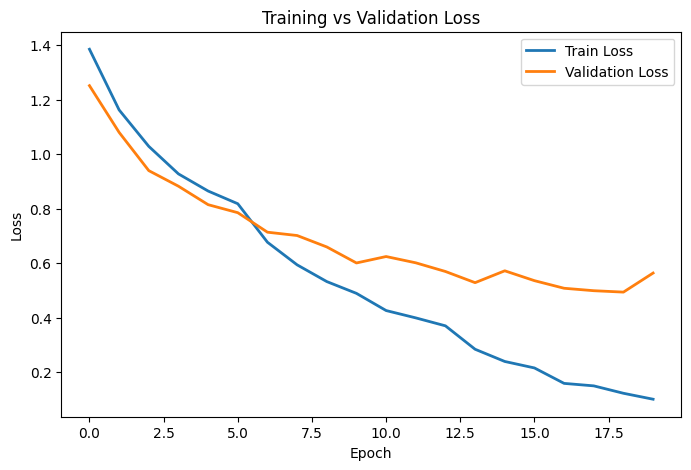

In [40]:

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay

model.eval()  
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())

# Compute metrics
accuracy = accuracy_score(all_labels, all_preds)
print(f"Validation Accuracy: {accuracy:.4f}")

print("Classification Report:")
print(classification_report(all_labels, all_preds))



Validation Accuracy: 0.8022
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85        15
           1       0.83      0.77      0.80        44
           2       0.89      0.83      0.86        60
           3       0.79      0.55      0.65        20
           4       0.70      0.86      0.77        43

    accuracy                           0.80       182
   macro avg       0.80      0.79      0.79       182
weighted avg       0.81      0.80      0.80       182



In [ ]:
print("Confusion Matrix:")
cm=confusion_matrix(all_labels, all_preds)
cm

Confusion Matrix:


array([[14,  0,  0,  1,  0],
       [ 0, 34,  2,  0,  8],
       [ 3,  5, 50,  0,  2],
       [ 0,  0,  3, 11,  6],
       [ 1,  2,  1,  2, 37]])